GitHub Repo:
https://github.com/ImmanuelOji/Last-FM-Data-Mining

## (A) Identification of Candidate Datasets

## Dataset 1 - Online Retail Dataset (UCI)

- Dataset name and source: Online Retail Dataset — UCI Machine Learning Repository
- Course topic alignment: Frequent Itemsets, Association Rule Mining
- Potential beyond-course techniques: Sequential Pattern Mining, Statistical validation of association rules
- Dataset size and structure: 500,000 transactions, Each row: Invoice, Product, Quantity, Timestamp
- Data types: Transaction ID, Product ID / Name, Timestamp, Numeric quantity
- Target variable(s): None
- Licensing or usage constraints: Public academic dataset

## Dataset 2 - Instacart Grocery Orders

- Dataset name and source: Instacart Market Basket Dataset
- Course topic alignment: Frequent Itemset Mining, Association Rules
- Potential beyond-course techniques: Sequential Pattern Mining, Recommendation modeling from rules
- Dataset size and structure: 3 million grocery orders, User → Orders → Products
- Data types: Order ID, Product ID, User ID, Timestamp / order sequence
- Target variable(s): None
- Licensing or usage constraints: Public dataset for research use

## Dataset 3 - Last.fm Music Listening Dataset

- Dataset name and source: Last.fm 1K - (GroupLens / Last.fm public dataset)
- Course topic alignment: Frequent Itemset Mining, Association Rule
- Potential beyond-course techniques: Sequential Pattern Mining, Recommendation modeling from association rules
- Dataset size and structure: 19 million listening events, User listening history over time
- Data types: User ID, Artist / Song ID, Timestamp, Listening events
- Target variable(s): None
- Licensing or usage constraints: Public academic dataset (research use allowed)

## (B) Comparative Analysis of Datasets

| Dimension | Online Retail Dataset | Instacart Grocery Dataset | Last.fm Music Listening Dataset |
|----------|----------------------|---------------------------|---------------------------------|
| **Supported Data Mining Tasks** | **Course:** Frequent Itemsets, Association Rules (market basket patterns) <br> **External:** Sequential Pattern Mining, statistical validation of rules | **Course:** Frequent Itemsets, Association Rules (grocery baskets) <br> **External:** Sequential Pattern Mining, recommendation modeling | **Course:** Frequent Itemsets, Association Rules (co-listened artists/songs) <br> **External:** Sequential Pattern Mining (temporal listening behavior), recommendation modeling |
| **Data Quality Issues** | Missing customer IDs, duplicate invoices, product cancellations, noisy product descriptions | Large dataset size, missing product metadata, order sparsity, repeated items | Requires session construction, noisy listening logs, possible missing timestamps, repeated listens |
| **Algorithmic Feasibility** | Moderate size (500K transactions); Apriori/FP-Growth feasible locally; sequential mining feasible after sampling | Very large (3M orders); may require sampling; FP-Growth feasible; sequential mining heavier | Large listening logs but can sample; FP-Growth feasible after basket construction; sequential mining manageable |
| **Bias Considerations** | Retail promotion bias, seasonal purchasing bias, customer sampling bias | Shopping habit bias, product availability bias, demographic skew | Platform-specific listening bias (Last.fm users not general population), popularity bias toward famous artists |
| **Ethical Considerations** | Low risk; anonymized transaction data | Low risk; anonymized consumer behavior | Low risk; anonymized listening data; recommendation analysis may reinforce popularity bias |


## (C) Dataset Selection

### Selected Dataset — Last.fm Music Listening Dataset

Reasons:
- The Last.fm Music Listening Dataset was selected because it strongly supports Frequent Itemset Mining and Association Rule Mining.
- Music listening behavior naturally forms transaction-style data where songs or artists listened within a session can be treated as baskets, making it well-suited for pattern discovery.
- The dataset enables Sequential Pattern Mining, a beyond-course technique, by leveraging timestamps to analyze temporal listening behavior and uncover order-sensitive patterns that traditional itemset mining cannot capture.

Trade-offs:
- Raw listening logs may require preprocessing to construct sessions or baskets.
- Dataset is large and may require sampling for computational feasibility.
- No labeled target variable (unsupervised pattern mining).

## (D) Exploratory Data Analysis

In [ ]:
#Download and extract dataset
import os
import urllib.request
import zipfile

# Dataset URL
DATA_URL = "https://files.grouplens.org/datasets/hetrec2011/hetrec2011-lastfm-2k.zip"

# Local paths
ZIP_PATH = "data/lastfm_dataset.zip"
EXTRACT_FOLDER = "data"

os.makedirs("data", exist_ok=True)

def download_dataset(url: str, to_path: str):
    if not os.path.exists(to_path):
        print(f"Downloading from {url} ...")
        urllib.request.urlretrieve(url, to_path)
        size = os.path.getsize(to_path) / (1024 * 1024)
        print(f"Saved to {to_path} ({size:.2f} MB)")
    else:
        print("Dataset already downloaded.")

def extract_required_files(zip_path: str, extract_to: str, required_files):
    print("Extracting required files...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        for file in zip_ref.namelist():
            for req in required_files:
                if file.endswith(req):
                    print(f"Extracting {req} ...")
                    zip_ref.extract(file, extract_to)

    print("Extraction complete.")

# Download ZIP
download_dataset(DATA_URL, ZIP_PATH)

# Extract needed files
required_files = ["user_artists.dat", "artists.dat"]
extract_required_files(ZIP_PATH, EXTRACT_FOLDER, required_files)

Dataset already downloaded.
Extracting required files...
Extracting artists.dat ...
Extracting artists.dat ...
Extracting user_artists.dat ...
Extracting artists.dat ...
Extraction complete.


Downloaded dataset zip file and extracted the the datasets i needed('user_artist.dat','artist.dat'), and stored it in my system

In [ ]:
import pandas as pd

# Load files
user_artists = pd.read_csv("data/user_artists.dat", sep="\t")
artists = pd.read_csv("data/artists.dat", sep="\t")

print("User-Artist shape:", user_artists.shape)
print("Artists shape:", artists.shape)

user_artists.head()

User-Artist shape: (92834, 3)
Artists shape: (17632, 4)


,userID,artistID,weight
0,2,51,13883
1,2,52,11690
2,2,53,11351
3,2,54,10300
4,2,55,8983


In [ ]:
user_artists.info()

<class 'pandas.DataFrame'>
RangeIndex: 92834 entries, 0 to 92833
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   userID    92834 non-null  int64
 1   artistID  92834 non-null  int64
 2   weight    92834 non-null  int64
dtypes: int64(3)
memory usage: 2.1 MB


The Last.fm dataset contains user listening interactions with artists.
Each row represents how many times a user listened to a specific artist.

In [ ]:
# checking for missing values
print("Missing values (user_artists):")
print(user_artists.isnull().sum())

print("\nMissing values (artists):")
print(artists.isnull().sum())

Missing values (user_artists):
userID      0
artistID    0
weight      0
dtype: int64

Missing values (artists):
id              0
name            0
url             0
pictureURL    444
dtype: int64


In [ ]:
#Checking for duplicates
duplicates = user_artists.duplicated().sum()
print("Duplicate rows:", duplicates)

if duplicates > 0:
    user_artists = user_artists.drop_duplicates()
    print("Duplicates removed.")

Duplicate rows: 0


The dataset required minimal cleaning. No missing values were present in the
`user_artists` table, and duplicate records were not detected. The `pictureURL`
column in the `artists` table contained missing values, but this column is not
relevant to frequent itemset or association rule mining and was therefore ignored.

In [ ]:
#Merge Artist Names
data = user_artists.merge(artists, left_on="artistID", right_on="id", how="left")

#transaction basket
baskets = data.groupby("userID")["name"].apply(list)

In [ ]:
data.head()

,userID,artistID,weight,id,name,url,pictureURL
0,2,51,13883,51,Duran Duran,http://www.last.fm/music/Duran+Duran,http://userserve-ak.last.fm/serve/252/155668.jpg
1,2,52,11690,52,Morcheeba,http://www.last.fm/music/Morcheeba,http://userserve-ak.last.fm/serve/252/46005111...
2,2,53,11351,53,Air,http://www.last.fm/music/Air,http://userserve-ak.last.fm/serve/252/251119.jpg
3,2,54,10300,54,Hooverphonic,http://www.last.fm/music/Hooverphonic,http://userserve-ak.last.fm/serve/252/40553471...
4,2,55,8983,55,Kylie Minogue,http://www.last.fm/music/Kylie+Minogue,http://userserve-ak.last.fm/serve/252/12740835...


In [ ]:
baskets.head()

userID
2    [Duran Duran, Morcheeba, Air, Hooverphonic, Ky...
3    [Pleq, Segue, Max Richter, Celer, Pjusk, Pleq ...
4    [Duran Duran, Air, Röyksopp, Coldplay, Moby, D...
5    [Air, Radiohead, Placebo, Keane, Muse, The Tig...
6    [George Michael, Keyshia Cole, Racionais MC's,...
Name: name, dtype: object

Merged the user_artists with artists to get their names then contructed a transaction basket. Each user is treated as a transaction, and the artists listened to by that user
form the item basket.

In [ ]:
#number of users, artists and total listening records
print("Number of users:", data["userID"].nunique())
print("Number of artists:", data["name"].nunique())
print("Total listening records:", len(data))

Number of users: 1892
Number of artists: 17632
Total listening records: 92834


In [ ]:
#EDA on basket size
basket_sizes = baskets.apply(len)

print("Average basket size:", basket_sizes.mean())
print("Median basket size:", basket_sizes.median())
print("Max basket size:", basket_sizes.max())
print("Min basket size:", basket_sizes.min())

Average basket size: 49.06659619450317
Median basket size: 50.0
Max basket size: 50
Min basket size: 1


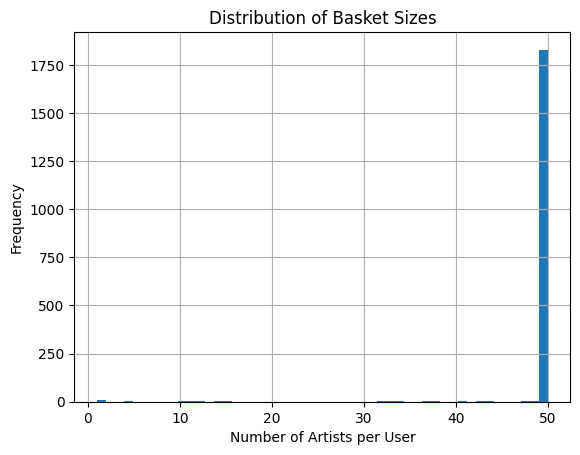

In [ ]:
#Basket Size Distribution
import matplotlib.pyplot as plt

basket_sizes.hist(bins=50)
plt.title("Distribution of Basket Sizes")
plt.xlabel("Number of Artists per User")
plt.ylabel("Frequency")
plt.show()

In [ ]:
#most popular artist
top_artists = data["name"].value_counts().head(20)
top_artists

name
Lady Gaga             611
Britney Spears        522
Rihanna               484
The Beatles           480
Katy Perry            473
Madonna               429
Avril Lavigne         417
Christina Aguilera    407
Muse                  400
Paramore              399
Beyoncé               397
Radiohead             393
Coldplay              369
Ke$ha                 362
Shakira               319
P!nk                  305
The Killers           304
Black Eyed Peas       304
Kylie Minogue         298
Miley Cyrus           286
Name: count, dtype: int64

The histogram shows the distribution of the number of artists listened to by each user. Most users have baskets containing approximately 50 artists, as indicated by the large peak near the upper range. Only a small number of users have very small baskets.The distribution suggests relatively consistent listening diversity across users.

### Bias Considerations

The Last.fm dataset reflects listening behavior of users on the Last.fm platform,
which may not represent the general population. The dataset may exhibit popularity
bias, where highly popular artists appear more frequently, potentially dominating
frequent itemsets and association rules. Additionally, user activity levels vary,
and highly active users may disproportionately influence discovered patterns.

### Initial Observations

- Basket sizes vary widely across users, indicating differences in listening diversity.
- A small number of artists dominate listening frequency, suggesting strong popularity bias.
- Most users listen to a limited subset of artists, resulting in sparse co-listening patterns.

### Hypotheses

- Highly popular artists will form strong frequent itemsets due to widespread listening.
- Rare artists may still form meaningful sequential patterns which will not captured by traditional itemset mining.

### Research Questions

1. What frequent artist combinations appear across users?
2. How do different support thresholds affect discovered association rules?
3. Do sequential listening patterns reveal structure beyond traditional frequent itemsets?
4. Can association rules be used to generate meaningful music recommendation patterns?
5. Will it be better to do the music recommendation with types of songs and not artists?